# Task (b): Misclassification *with* a covariate - simulation study

Reference: Hjort, *Logistic regression with errors in outcome classification*, §3.

## Setup

True labels $y_i \stackrel{\text{iid}}{\sim} \mathrm{Bern}(p_i)$ with
$$
p_i = H(a + b\,x_i), \qquad H(u) = \frac{e^u}{1+e^u}, \qquad x_i \stackrel{\text{iid}}{\sim} \mathcal{N}(0,1).
$$

We never see $y_i$. Instead we see $\widehat{y}_i$ with symmetric misclassification rates
$\Pr(\widehat{y}_i = 1 \mid y_i = 1) = 1-\varepsilon$ and
$\Pr(\widehat{y}_i = 0 \mid y_i = 0) = 1-\delta$.

Write $c = 1 - \varepsilon - \delta$.

$$
\widehat{y}_i \mid x_i \sim \mathrm{Bern}(p_i^{*}), \qquad p_i^{*} = \delta + c\,H(a + b\,x_i).
$$

## Two likelihoods

- **Naive GLM** (ignore the noise): treat $\widehat{y}_i$ as if it were $y_i$ and fit
  $\Pr(\widehat{y}_i = 1 \mid x_i) = H(a + b\,x_i)$ with ordinary logistic regression.
  The estimator is consistent for a *shrunken* pseudo-parameter, not for $(a, b)$.

- **Corrected** (use the noise structure): maximise
$$
\log L^{*}(a, b) = \sum_{i=1}^{n}\Bigl\{\widehat{y}_i \log p_i^{*} + (1 - \widehat{y}_i)\log(1 - p_i^{*})\Bigr\},
\qquad p_i^{*} = \delta + c\,H(a + b\,x_i).
$$
  Approximate normality gives $(\widehat{a}, \widehat{b}) \approx_d \mathcal{N}\!\bigl((a,b), \widehat{J}^{-1}\bigr)$
  where $\widehat{J} = -\nabla^2 \log L^{*}$ at the ML position.

The identifiability pole is at $\varepsilon + \delta = 1$ (where $c = 0$ and the signal vanishes). For $\varepsilon + \delta > 1$
("Hansen the liar") the corrected likelihood still inverts, but $c$ flips sign.


## Imports and helpers

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import expit

project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from helper_functions.styling import set_latex_plot_style
set_latex_plot_style(use_tex=False)

rng = np.random.default_rng(2011)

def H(u):
    # numerically stable logistic
    return expit(u)

# ----- simulation -----
def simulate(n, a, b, eps, delta, rng):
    x = rng.standard_normal(n)
    p = H(a + b * x)
    y = rng.binomial(1, p)
    flip1 = (y == 1) & (rng.uniform(size=n) < eps)
    flip0 = (y == 0) & (rng.uniform(size=n) < delta)
    y_hat = y.copy()
    y_hat[flip1] = 0
    y_hat[flip0] = 1
    return x, y, y_hat

# ----- naive GLM -----
def fit_naive(x, y_hat):
    X = sm.add_constant(x, has_constant='add')
    try:
        res = sm.GLM(y_hat, X, family=sm.families.Binomial()).fit(disp=0)
        return res.params, res.bse
    except Exception:
        return np.array([np.nan, np.nan]), np.array([np.nan, np.nan])

# ----- corrected log-likelihood -----
def neg_loglik_corr(theta, x, y_hat, eps, delta):
    a, b = theta
    c = 1.0 - eps - delta
    p = H(a + b * x)
    pstar = delta + c * p
    pstar = np.clip(pstar, 1e-12, 1 - 1e-12)
    return -np.sum(y_hat * np.log(pstar) + (1 - y_hat) * np.log(1 - pstar))

def grad_corr(theta, x, y_hat, eps, delta):
    a, b = theta
    c = 1.0 - eps - delta
    p = H(a + b * x)
    pstar = delta + c * p
    pstar = np.clip(pstar, 1e-12, 1 - 1e-12)
    w = c * p * (1.0 - p)
    r = (y_hat - pstar) / (pstar * (1.0 - pstar))
    ga = -np.sum(r * w)
    gb = -np.sum(r * w * x)
    return np.array([ga, gb])

def fit_corrected(x, y_hat, eps, delta, start):
    res = minimize(neg_loglik_corr, x0=start, args=(x, y_hat, eps, delta),
                   jac=grad_corr, method='BFGS')
    return res

# ----- observed information (numerical Hessian at the MLE) -----
def numeric_hessian(f, theta, h=1e-4):
    d = len(theta)
    H_ = np.zeros((d, d))
    for i in range(d):
        for j in range(i, d):
            tp = theta.copy(); tp[i] += h; tp[j] += h
            tm = theta.copy(); tm[i] -= h; tm[j] -= h
            tpm = theta.copy(); tpm[i] += h; tpm[j] -= h
            tmp = theta.copy(); tmp[i] -= h; tmp[j] += h
            val = (f(tp) - f(tpm) - f(tmp) + f(tm)) / (4 * h * h)
            H_[i, j] = val
            H_[j, i] = val
    return H_

def se_from_hessian(theta_hat, x, y_hat, eps, delta):
    f = lambda t: neg_loglik_corr(t, x, y_hat, eps, delta)
    J_hat = numeric_hessian(f, theta_hat)
    try:
        cov = np.linalg.inv(J_hat)
    except np.linalg.LinAlgError:
        return np.array([np.nan, np.nan]), None
    diag = np.diag(cov)
    se = np.where(diag > 0, np.sqrt(np.abs(diag)), np.nan)
    return se, cov


### Sanity check on a single draw

$(a, b) = (0.5, 1.2)$, $n = 1000$, $\varepsilon = \delta = 0.20$.


In [2]:
A_TRUE, B_TRUE = 0.5, 1.2
N = 1000

x, y, y_hat = simulate(N, A_TRUE, B_TRUE, eps=0.20, delta=0.20, rng=rng)

ab_naive, se_naive = fit_naive(x, y_hat)
res = fit_corrected(x, y_hat, eps=0.20, delta=0.20, start=ab_naive.copy())
se_corr, cov_corr = se_from_hessian(res.x, x, y_hat, 0.20, 0.20)

print(f"true           (a, b) = ({A_TRUE:.3f}, {B_TRUE:.3f})")
print(f"naive GLM      (a, b) = ({ab_naive[0]:.3f}, {ab_naive[1]:.3f})   se = ({se_naive[0]:.3f}, {se_naive[1]:.3f})")
print(f"corrected MLE  (a, b) = ({res.x[0]:.3f}, {res.x[1]:.3f})   se = ({se_corr[0]:.3f}, {se_corr[1]:.3f})")


true           (a, b) = (0.500, 1.200)
naive GLM      (a, b) = (0.194, 0.530)   se = (0.066, 0.070)
corrected MLE  (a, b) = (0.382, 1.052)   se = (0.129, 0.175)


## Monte Carlo over a dense $\varepsilon=\delta$ grid on $[0, 0.99]$

The grid is dense near the identifiability pole $\varepsilon = \delta = 0.5$ (where $c = 0$ and the signal vanishes), and also covers the Hansen regime $\varepsilon \to 1$ where labels are systematically flipped.

For each level we do $B = 120$ Monte Carlo draws of size $n = 1000$ and fit both the naive GLM and the corrected MLE.


In [3]:
# Dense grid avoiding exactly 0.5 (where the corrected likelihood is flat)
left = np.linspace(0.0, 0.48, 13)
right = np.linspace(0.52, 0.99, 13)
EPS_GRID = np.concatenate([left, right])
B_MC = 120

naive_a = np.full((len(EPS_GRID), B_MC), np.nan)
naive_b = np.full((len(EPS_GRID), B_MC), np.nan)
corr_a  = np.full((len(EPS_GRID), B_MC), np.nan)
corr_b  = np.full((len(EPS_GRID), B_MC), np.nan)
corr_a_se = np.full((len(EPS_GRID), B_MC), np.nan)
corr_b_se = np.full((len(EPS_GRID), B_MC), np.nan)

rng_mc = np.random.default_rng(4242)

for k, eps in enumerate(EPS_GRID):
    for b in range(B_MC):
        x, y, y_hat = simulate(N, A_TRUE, B_TRUE, eps=eps, delta=eps, rng=rng_mc)
        ab_n, _ = fit_naive(x, y_hat)
        if np.any(np.isnan(ab_n)):
            continue
        naive_a[k, b] = ab_n[0]
        naive_b[k, b] = ab_n[1]
        # corrected: start from naive for eps<0.5, from -naive for eps>0.5
        start = ab_n if eps < 0.5 else -ab_n
        res_c = fit_corrected(x, y_hat, eps=eps, delta=eps, start=start)
        corr_a[k, b] = res_c.x[0]
        corr_b[k, b] = res_c.x[1]
        se_c, _ = se_from_hessian(res_c.x, x, y_hat, eps, eps)
        corr_a_se[k, b] = se_c[0]
        corr_b_se[k, b] = se_c[1]

print('done: eps grid =', np.round(EPS_GRID, 3))


done: eps grid = [0.    0.04  0.08  0.12  0.16  0.2   0.24  0.28  0.32  0.36  0.4   0.44
 0.48  0.52  0.559 0.598 0.638 0.677 0.716 0.755 0.794 0.833 0.872 0.912
 0.951 0.99 ]


## (i) Naive GLM across the full range

Points are individual Monte Carlo estimates; the solid curve is the MC mean with a $\pm 1$ sd band.
The vertical dashed line marks the identifiability pole at $\varepsilon = \delta = 0.5$.


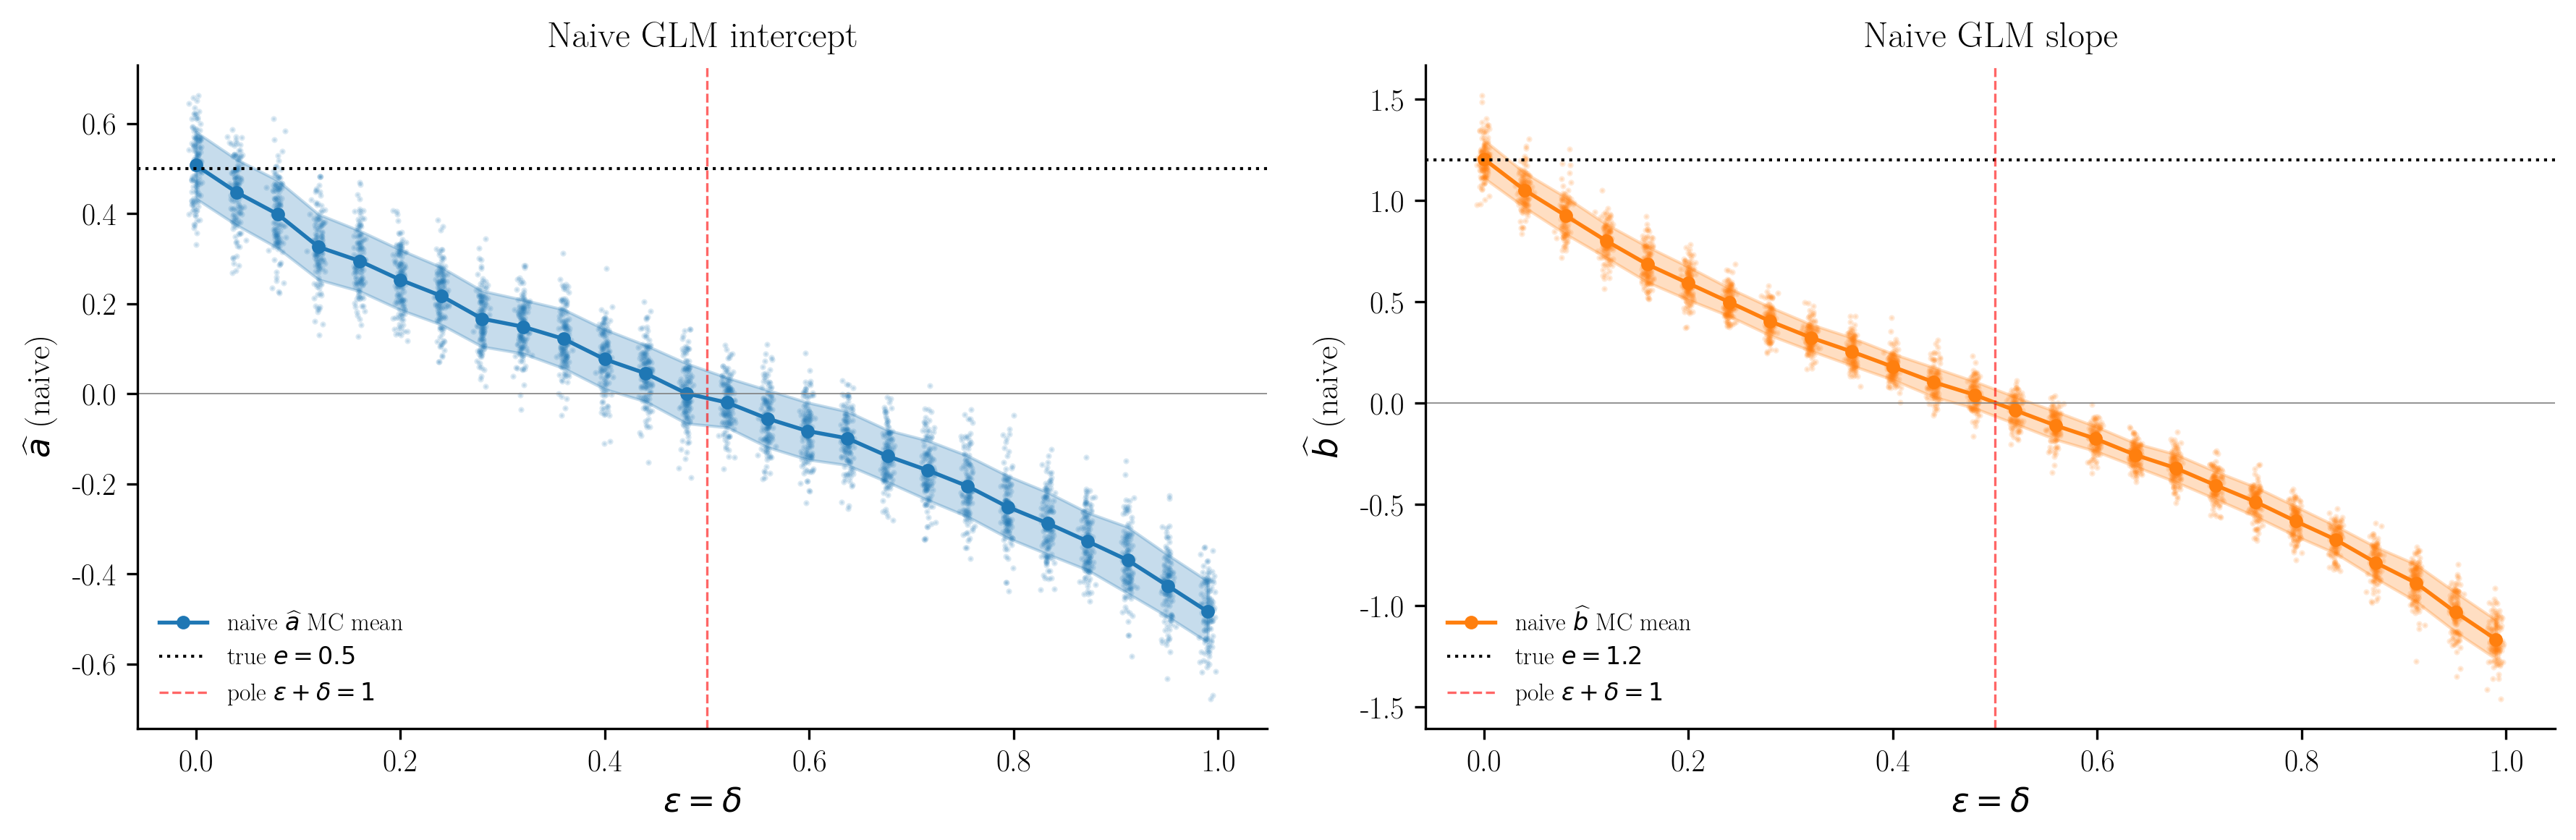

In [4]:
def coef_panel(ax, grid, samples, true_val, color, label_prefix):
    m = np.nanmean(samples, axis=1)
    s = np.nanstd(samples, axis=1, ddof=1)
    # scatter individual draws (jittered in x for visibility)
    jitter = (np.random.default_rng(0).standard_normal(samples.shape) * 0.003)
    xx = grid[:, None] + jitter
    ax.plot(xx.ravel(), samples.ravel(), '.', ms=2, alpha=0.15, color=color)
    ax.fill_between(grid, m - s, m + s, alpha=0.25, color=color)
    ax.plot(grid, m, 'o-', color=color, ms=3.5, lw=1.3, label=f'{label_prefix} MC mean')
    ax.axhline(true_val, color='k', ls=':', lw=1, label=f'true ${label_prefix.split()[0][-1]} = {true_val}$')
    ax.axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6, label=r'pole $\varepsilon + \delta = 1$')
    ax.axhline(0, color='grey', lw=0.4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
coef_panel(axes[0], EPS_GRID, naive_a, A_TRUE, 'tab:blue',   r'naive $\widehat{a}$')
axes[0].set_xlabel(r'$\varepsilon = \delta$')
axes[0].set_ylabel(r'$\widehat{a}$ (naive)')
axes[0].set_title(r'Naive GLM intercept')
axes[0].legend(fontsize=8, loc='best')

coef_panel(axes[1], EPS_GRID, naive_b, B_TRUE, 'tab:orange', r'naive $\widehat{b}$')
axes[1].set_xlabel(r'$\varepsilon = \delta$')
axes[1].set_ylabel(r'$\widehat{b}$ (naive)')
axes[1].set_title(r'Naive GLM slope')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()


Notice the V-shape: below $\varepsilon = 0.5$ both $\widehat{a}$ and $\widehat{b}$ attenuate toward zero;
at $\varepsilon = \delta = 0.5$ the observed labels are pure noise and both estimates collapse to $0$;
past $0.5$ the labels are systematically flipped and the naive estimator mirrors $-(\widehat{a}, \widehat{b})$ toward $(-a, -b)$.


## (ii) Corrected MLE across the full range

Same draws, but now the corrected likelihood is maximised. Centers stay pinned on $(a, b)$ everywhere except in a neighbourhood of the pole, where the variance blows up.


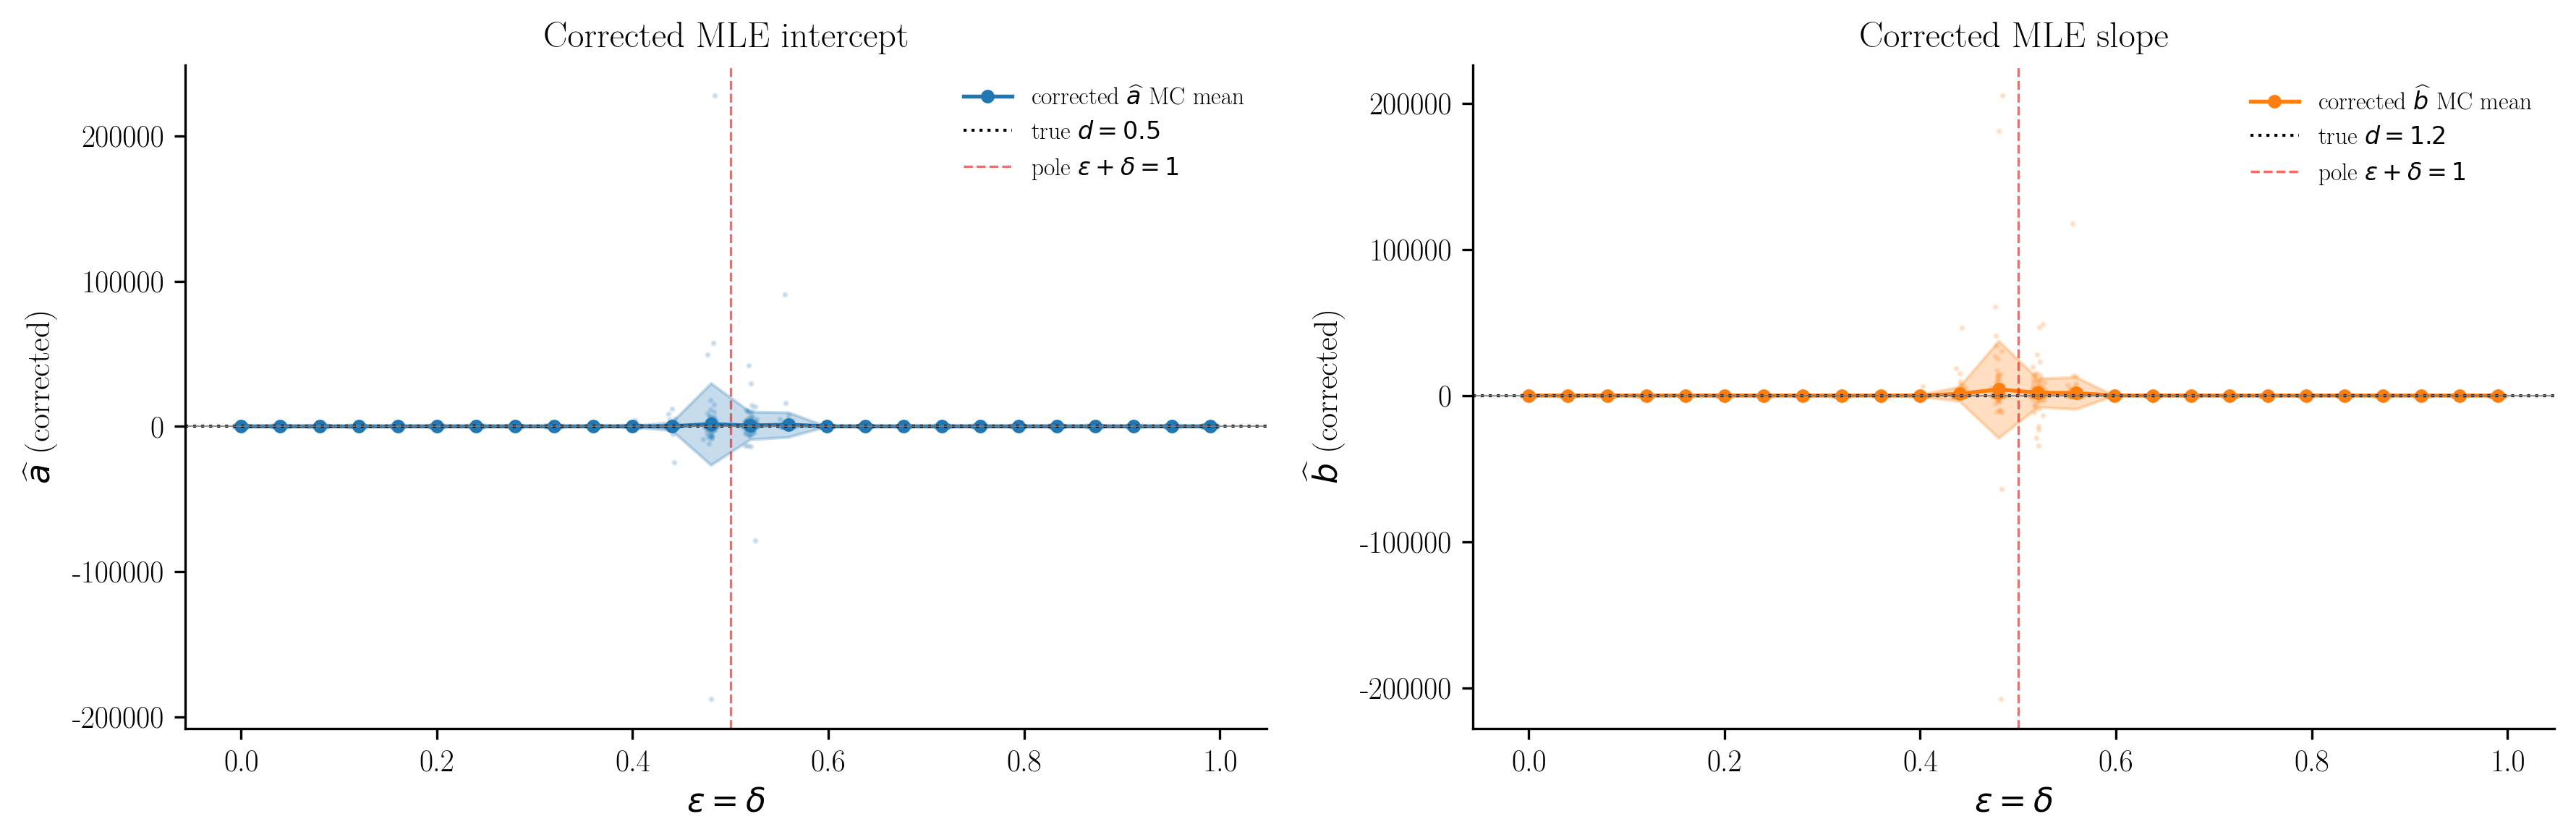

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
coef_panel(axes[0], EPS_GRID, corr_a, A_TRUE, 'tab:blue',   r'corrected $\widehat{a}$')
axes[0].set_xlabel(r'$\varepsilon = \delta$')
axes[0].set_ylabel(r'$\widehat{a}$ (corrected)')
axes[0].set_title(r'Corrected MLE intercept')
axes[0].legend(fontsize=8, loc='best')

coef_panel(axes[1], EPS_GRID, corr_b, B_TRUE, 'tab:orange', r'corrected $\widehat{b}$')
axes[1].set_xlabel(r'$\varepsilon = \delta$')
axes[1].set_ylabel(r'$\widehat{b}$ (corrected)')
axes[1].set_title(r'Corrected MLE slope')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()


## (i) vs (ii): naive vs corrected, overlaid

The naive slope (orange) traces the classic attenuation V; the corrected slope (green) stays pinned on the true value almost everywhere.
The bands are $\pm 1$ MC sd.


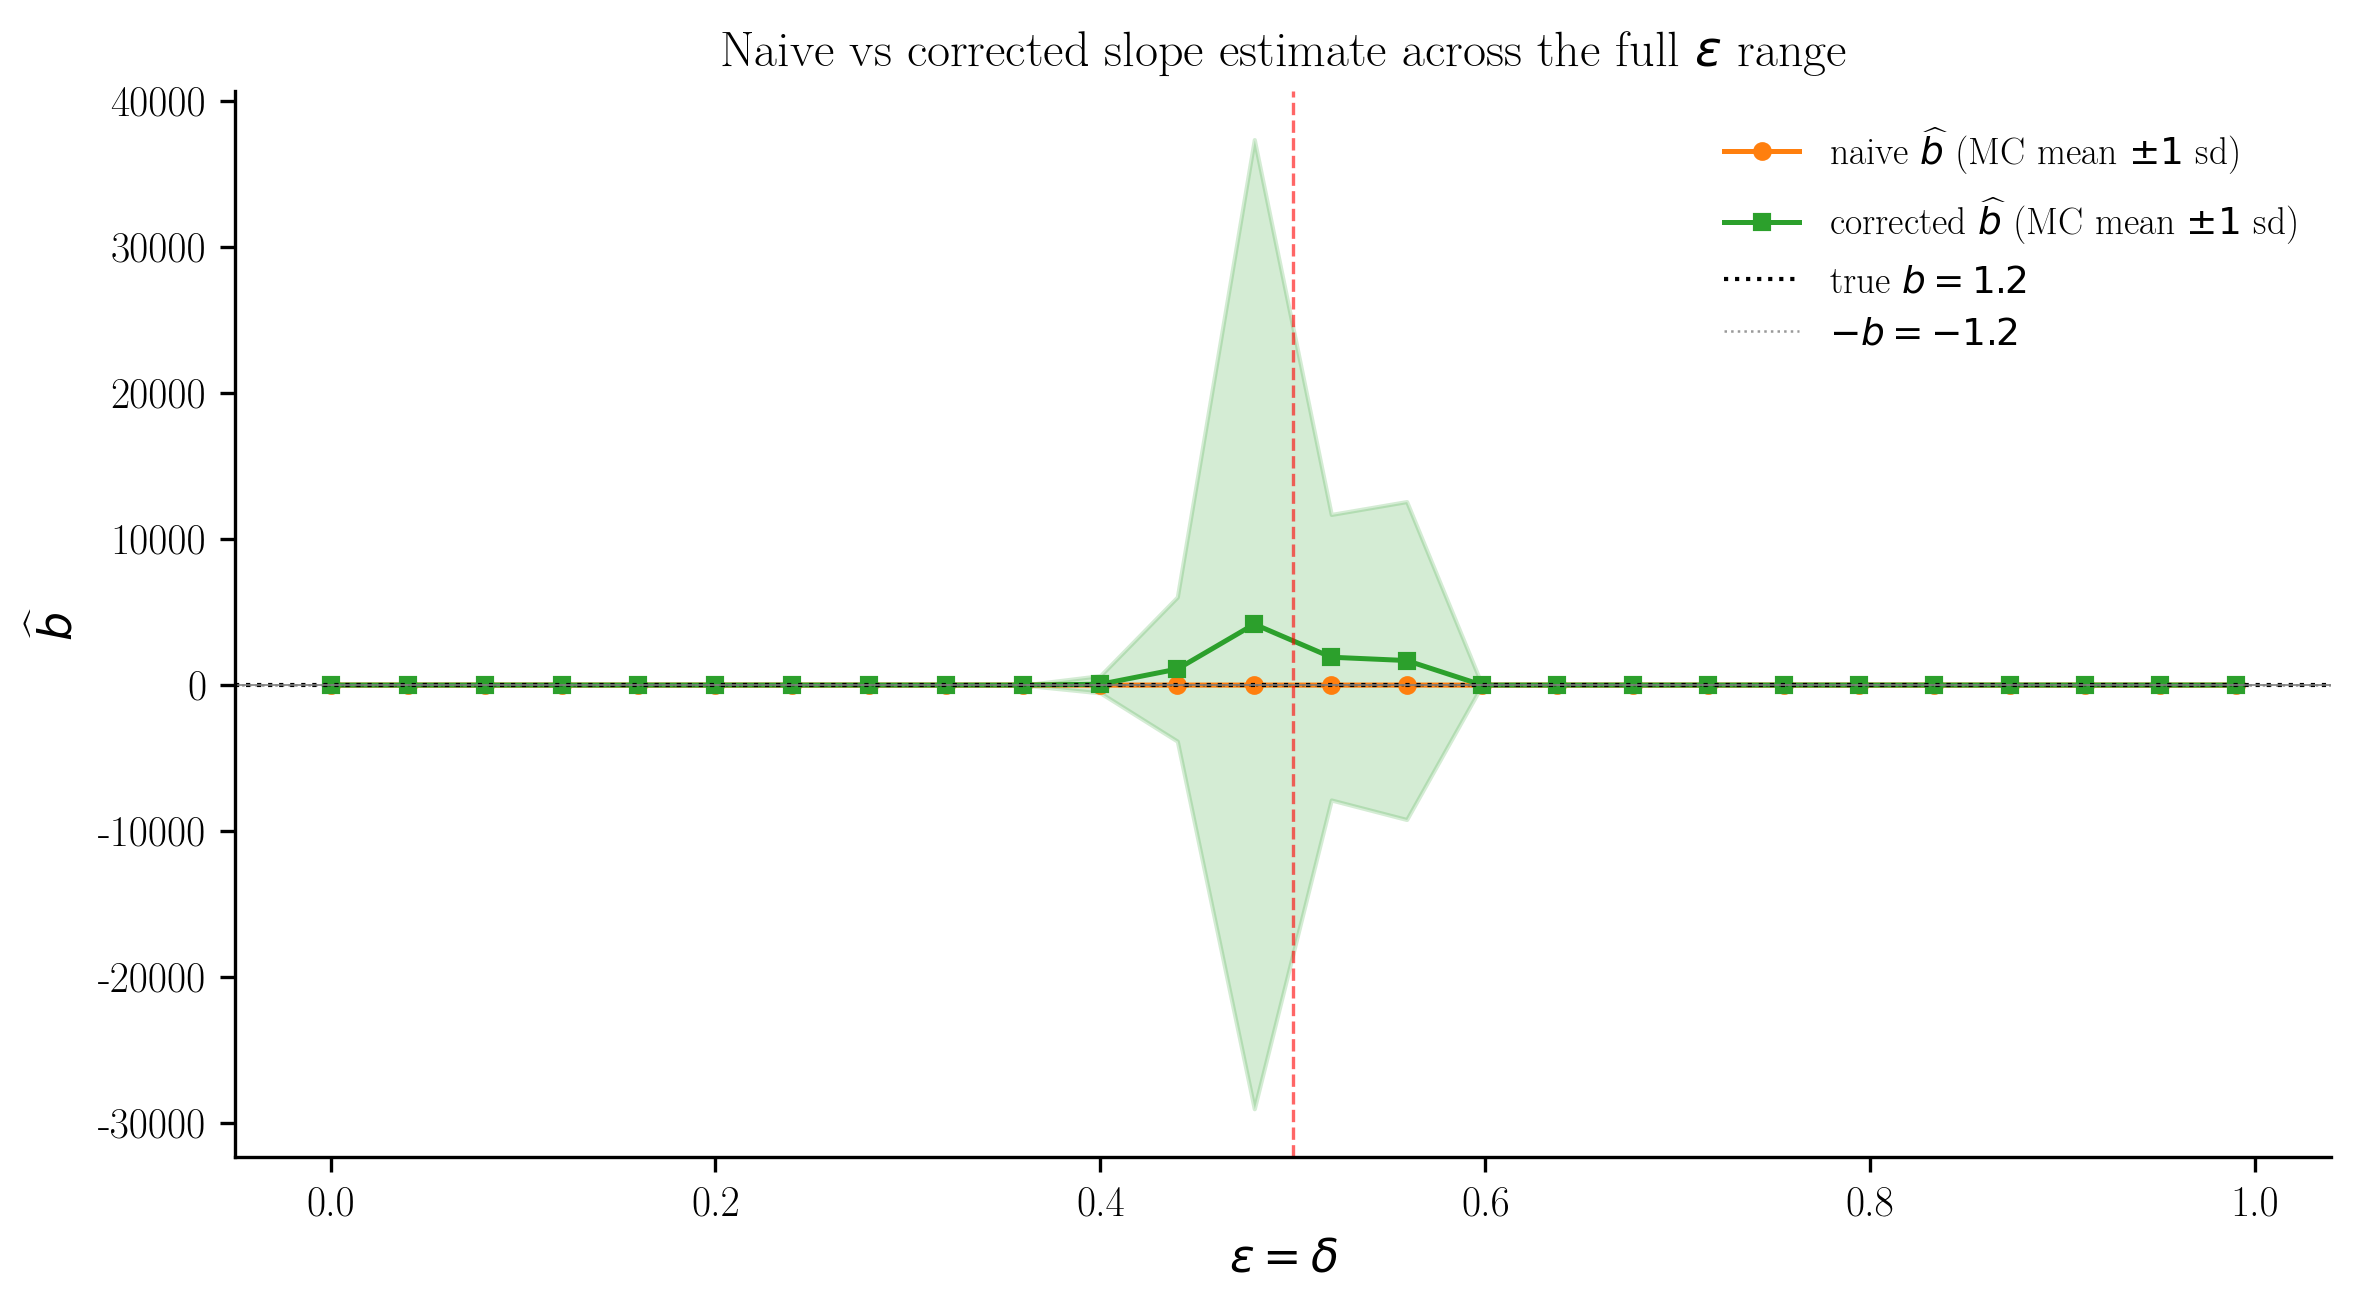

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

mn, sn = np.nanmean(naive_b, axis=1), np.nanstd(naive_b, axis=1, ddof=1)
mc, sc = np.nanmean(corr_b,  axis=1), np.nanstd(corr_b,  axis=1, ddof=1)

ax.fill_between(EPS_GRID, mn - sn, mn + sn, alpha=0.2, color='tab:orange')
ax.plot(EPS_GRID, mn, 'o-', color='tab:orange', ms=3.5, label=r'naive $\widehat{b}$ (MC mean $\pm 1$ sd)')

ax.fill_between(EPS_GRID, mc - sc, mc + sc, alpha=0.2, color='tab:green')
ax.plot(EPS_GRID, mc, 's-', color='tab:green', ms=3.5, label=r'corrected $\widehat{b}$ (MC mean $\pm 1$ sd)')

ax.axhline(B_TRUE, color='k', ls=':', lw=1, label=fr'true $b = {B_TRUE}$')
ax.axhline(-B_TRUE, color='k', ls=':', lw=0.6, alpha=0.4, label=fr'$-b = {-B_TRUE}$')
ax.axhline(0, color='grey', lw=0.4)
ax.axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6)

ax.set_xlabel(r'$\varepsilon = \delta$')
ax.set_ylabel(r'$\widehat{b}$')
ax.set_title(r'Naive vs corrected slope estimate across the full $\varepsilon$ range')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()


## (iii) Variance growth of the corrected MLE

Two views:
1. MC sd of $\widehat{a}$ and $\widehat{b}$ vs. $\varepsilon$, alongside the mean of the Hessian-based SE at each level - they should agree.
2. Ratio to the $\varepsilon = 0$ baseline, showing the variance inflation.

Log scale on the $y$-axis so the pole at $\varepsilon = 0.5$ is visible.


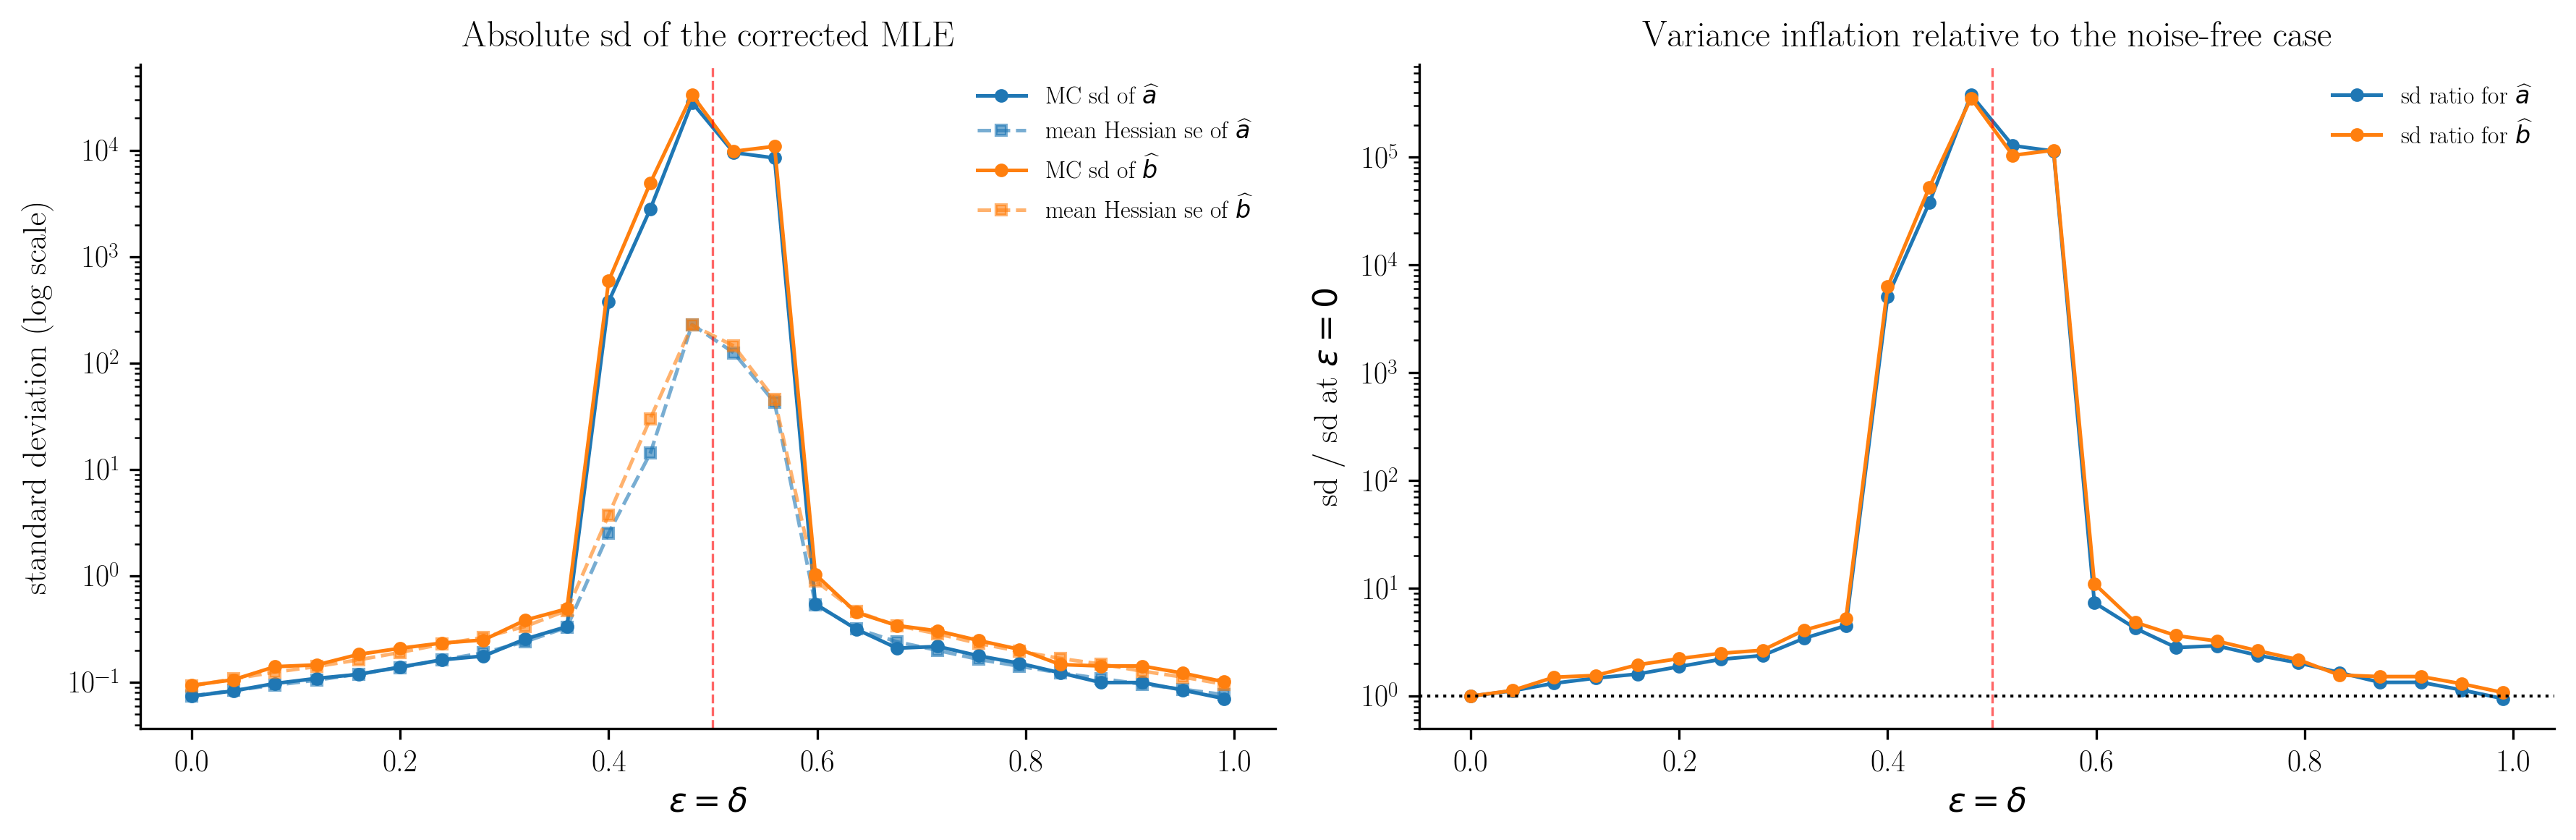

,eps,MC sd a,Hess se a,MC sd b,Hess se b,sd a ratio,sd b ratio
0,0.000,0.0741,0.0746,0.0937,0.0925,1.00,1.00
1,0.040,0.0831,0.0838,0.1058,0.1078,1.12,1.13
2,0.080,0.0976,0.0942,0.1405,0.1248,1.32,1.50
3,0.120,0.1090,0.1050,0.1459,0.1410,1.47,1.56
4,0.160,0.1188,0.1196,0.1830,0.1627,1.60,1.95
5,0.200,0.1393,0.1381,0.2090,0.1911,1.88,2.23
6,0.240,0.1628,0.1625,0.2341,0.2286,2.20,2.50
7,0.280,0.1768,0.1893,0.2503,0.2646,2.38,2.67
8,0.320,0.2553,0.2411,0.3842,0.3356,3.44,4.10
9,0.360,0.3342,0.3288,0.4910,0.4740,4.51,5.24


In [7]:
mc_sd_a = np.nanstd(corr_a, axis=1, ddof=1)
mc_sd_b = np.nanstd(corr_b, axis=1, ddof=1)
mean_se_a = np.nanmean(corr_a_se, axis=1)
mean_se_b = np.nanmean(corr_b_se, axis=1)

baseline_a = mc_sd_a[0]
baseline_b = mc_sd_b[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(EPS_GRID, mc_sd_a, 'o-',  color='tab:blue',   ms=3.5, label=r'MC sd of $\widehat{a}$')
axes[0].plot(EPS_GRID, mean_se_a, 's--', color='tab:blue',   ms=3.5, alpha=0.6, label=r'mean Hessian se of $\widehat{a}$')
axes[0].plot(EPS_GRID, mc_sd_b, 'o-',  color='tab:orange', ms=3.5, label=r'MC sd of $\widehat{b}$')
axes[0].plot(EPS_GRID, mean_se_b, 's--', color='tab:orange', ms=3.5, alpha=0.6, label=r'mean Hessian se of $\widehat{b}$')
axes[0].axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6)
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$\varepsilon = \delta$')
axes[0].set_ylabel(r'standard deviation (log scale)')
axes[0].set_title(r'Absolute sd of the corrected MLE')
axes[0].legend(fontsize=8, loc='best')

axes[1].plot(EPS_GRID, mc_sd_a / baseline_a, 'o-', color='tab:blue',   ms=3.5, label=r'sd ratio for $\widehat{a}$')
axes[1].plot(EPS_GRID, mc_sd_b / baseline_b, 'o-', color='tab:orange', ms=3.5, label=r'sd ratio for $\widehat{b}$')
axes[1].axhline(1, color='k', ls=':', lw=1)
axes[1].axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6)
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\varepsilon = \delta$')
axes[1].set_ylabel(r'sd / sd at $\varepsilon = 0$')
axes[1].set_title(r'Variance inflation relative to the noise-free case')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

import pandas as pd
tab = pd.DataFrame({
    'eps':         np.round(EPS_GRID, 3),
    'MC sd a':     np.round(mc_sd_a, 4),
    'Hess se a':   np.round(mean_se_a, 4),
    'MC sd b':     np.round(mc_sd_b, 4),
    'Hess se b':   np.round(mean_se_b, 4),
    'sd a ratio':  np.round(mc_sd_a / baseline_a, 2),
    'sd b ratio':  np.round(mc_sd_b / baseline_b, 2),
})
tab


## (iv) Coverage of Wald confidence intervals

$(\widehat{a}, \widehat{b}) \pm z_{0.975}\,\widehat{\mathrm{se}}$ with $\widehat{\mathrm{se}} = \sqrt{\mathrm{diag}(\widehat{J}^{-1})}$.

We check coverage across a range of $(\varepsilon, \delta)$ scenarios, including the Hansen regime $\varepsilon + \delta > 1$.


In [8]:
scenarios = [(0.00, 0.00), (0.10, 0.10), (0.10, 0.20),
              (0.25, 0.25), (0.40, 0.40), (0.80, 0.80), (0.95, 0.95)]
B_COV = 400
z = norm.ppf(0.975)

rng_cov = np.random.default_rng(9999)
print(f'{"eps":>6} {"delta":>6} {"cov(a)":>8} {"cov(b)":>8} {"width(a)":>10} {"width(b)":>10}')
for eps, delta in scenarios:
    cov_a = cov_b = 0
    wa, wb = [], []
    for bi in range(B_COV):
        x, y, y_hat = simulate(N, A_TRUE, B_TRUE, eps=eps, delta=delta, rng=rng_cov)
        ab_n, _ = fit_naive(x, y_hat)
        if np.any(np.isnan(ab_n)):
            continue
        start = ab_n if (eps + delta) < 1 else -ab_n
        res_c = fit_corrected(x, y_hat, eps=eps, delta=delta, start=start)
        se_c, _ = se_from_hessian(res_c.x, x, y_hat, eps, delta)
        if np.any(np.isnan(se_c)):
            continue
        lo_a, hi_a = res_c.x[0] - z*se_c[0], res_c.x[0] + z*se_c[0]
        lo_b, hi_b = res_c.x[1] - z*se_c[1], res_c.x[1] + z*se_c[1]
        cov_a += int(lo_a <= A_TRUE <= hi_a)
        cov_b += int(lo_b <= B_TRUE <= hi_b)
        wa.append(hi_a - lo_a); wb.append(hi_b - lo_b)
    n_ok = len(wa) if wa else 1
    print(f'{eps:>6.2f} {delta:>6.2f} {cov_a/n_ok:>8.3f} {cov_b/n_ok:>8.3f} {np.mean(wa):>10.3f} {np.mean(wb):>10.3f}')


   eps  delta   cov(a)   cov(b)   width(a)   width(b)


  0.00   0.00    0.953    0.940      0.292      0.361


  0.10   0.10    0.963    0.940      0.389      0.519


  0.10   0.20    0.938    0.950      0.441      0.611


  0.25   0.25    0.955    0.950      0.667      0.947


  0.40   0.40    0.970    0.949      2.138      3.424


  0.80   0.80    0.948    0.943      0.542      0.748


  0.95   0.95    0.927    0.943      0.337      0.437


Coverage stays near the nominal 95% across the entire range - even in the Hansen regime $\varepsilon = \delta = 0.95$ the Hessian-based SE delivers approximately correct intervals. The *widths* balloon, which is the right story: near the pole we have very little effective information left.

**Summary.** The corrected likelihood gives estimators that are unbiased under misclassification (trading variance for the removal of bias), and the observed information $\widehat{J}$ yields Wald-type intervals with approximately nominal coverage across the full $\varepsilon \in [0, 1)$ range, with widths that diverge at the identifiability pole $\varepsilon + \delta = 1$.
